<a href="https://colab.research.google.com/github/2403A51355/ml_lab/blob/main/ML_Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("/content/boston.csv")

In [7]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [8]:
x=df.drop("MEDV",axis=1)
y=df["MEDV"]

In [9]:
x=np.array(x)
y=np.array(y).reshape(-1,1)


In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.3,random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [12]:
from sklearn.linear_model import Ridge

In [13]:
from sklearn.linear_model import RidgeCV
alphas=np.logspace(-3,3,7)
ridge_cv=RidgeCV(alphas=alphas,cv=10)#k=10 cross vadlidation
ridge_cv.fit(x_train,y_train)
print("best alpha",ridge_cv.alpha_)


best alpha 10.0


In [14]:
best_ridge=Ridge(alpha=ridge_cv.alpha_)
best_ridge.fit(x_train,y_train)
y_pred=best_ridge.predict(x_test)

In [15]:
from sklearn.metrics import mean_squared_error,r2_score

In [16]:

mse = mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Squared Error: 21.81124307149158
Root Mean Squared Error: 4.670250857447765
R-squared: 0.7072830902371281


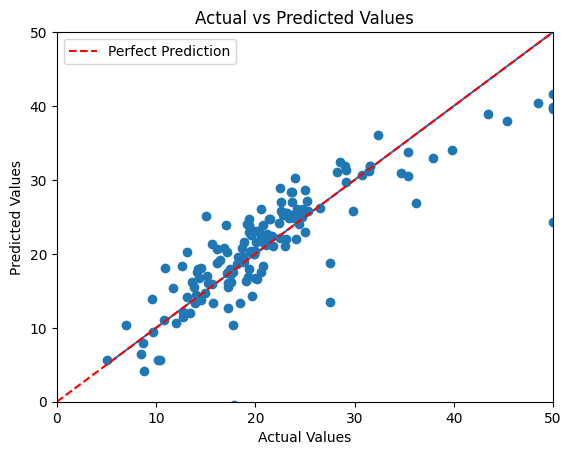

In [17]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)])
max_val = max(np.max(y_test), np.max(y_pred))
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
plt.legend()
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [18]:
from sklearn.linear_model import Lasso

In [19]:
from sklearn.linear_model import LassoCV
alphas=np.logspace(-3,3,7)
lasso_cv=LassoCV(alphas=alphas,cv=10)
lasso_cv.fit(x_train,y_train)
print("best alpha",lasso_cv.alpha_)

best alpha 0.001


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [20]:
best_ridge=Lasso(alpha=lasso_cv.alpha_)
best_ridge.fit(x_train,y_train)
y_pred=best_ridge.predict(x_test)

In [21]:
from sklearn.metrics import mean_squared_error,r2_score

In [22]:
mse = mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Squared Error: 21.521510718492532
Root Mean Squared Error: 4.63912822828735
R-squared: 0.7111714316191495


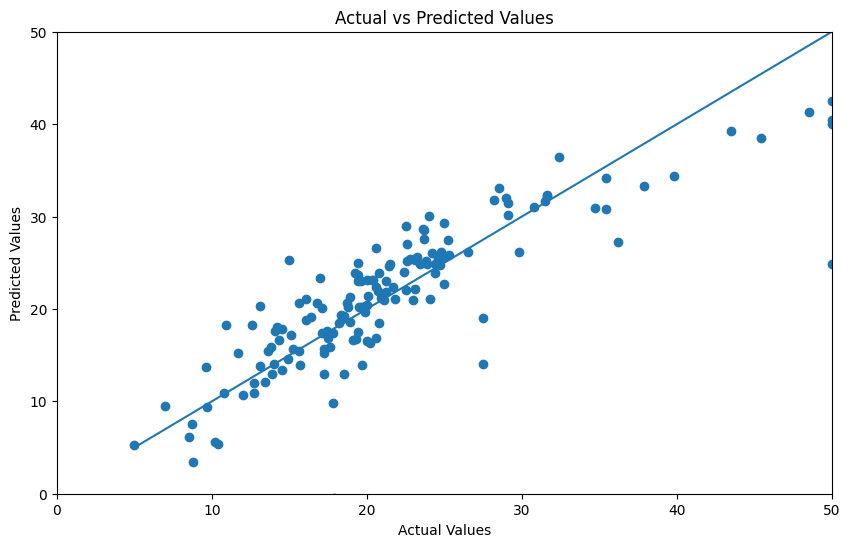

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)])
max_val=max(np.max(y_test),np.max(y_pred))
plt.xlim(0,max_val)
plt.ylim(0,max_val)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model = LinearRegression()
model.fit(x_train,y_train)
from sklearn.metrics import mean_squared_error,r2_score

In [26]:
mse=mean_squared_error(y_test,y_pred)
print("Mean squared error:",mse)
rmse=np.sqrt(mse)
print("Root mean squared error:",rmse)
R2= r2_score(y_test,y_pred)
print("R2 score:",R2)

Mean squared error: 21.521510718492532
Root mean squared error: 4.63912822828735
R2 score: 0.7111714316191495


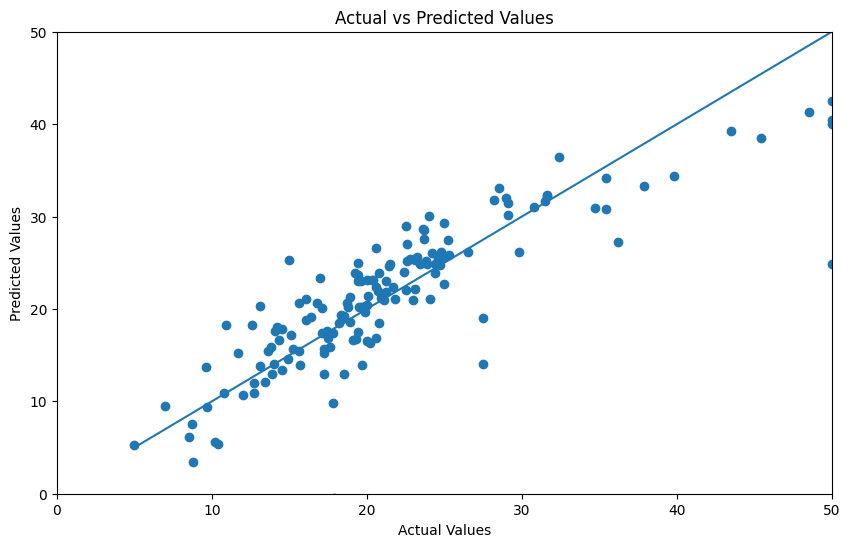

In [27]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)])
max_val=max(np.max(y_test),np.max(y_pred))
plt.xlim(0,max_val)
plt.ylim(0,max_val)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()